# One solve, many questions: `wrt=` blocks, prediction bands, `retain_kkt()`

The held KKT factor answers more than the fitted block's covariance.
`wrt=` reduces onto ANY block of the solve's variables, post-solve: a
sub-block marginal, a predicted-trajectory band, a query conditioned on
an active bound. And with `retain_kkt()` the factor is kept with
nothing declared at all, so the same questions work when no block is
THE fitted set.

In [1]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo

import pyomo_pounce
from pyomo_pounce import (
    covariance, declare_fitted, declare_residual, information,
    retain_kkt)

rng = np.random.default_rng(4)
A_TRUE, K_TRUE, SIG_TRUE = 2.0, 0.9, 0.05
t_data = np.linspace(0.0, 4.0, 30)
y_data = (A_TRUE * np.exp(-K_TRUE * t_data)
          + SIG_TRUE * rng.standard_normal(len(t_data)))


def build(t, y, declare=True):
    m = pyo.ConcreteModel()
    m.I = pyo.RangeSet(0, len(t) - 1)
    m.A = pyo.Var(initialize=1.0)
    m.k = pyo.Var(initialize=1.0)
    m.r = pyo.Var(m.I, initialize=0.0)
    m.res = pyo.Constraint(
        m.I, rule=lambda mm, i: mm.r[i]
        == float(y[i]) - mm.A * pyo.exp(-mm.k * float(t[i])))
    m.obj = pyo.Objective(expr=sum(m.r[i] ** 2 for i in m.I))
    if declare:
        declare_fitted(m.A, m.k)
        declare_residual(m.r)
    return m

m = build(t_data, y_data)
pyo.SolverFactory("pounce").solve(m, tee=True)
cov = covariance(m)
print(f"A = {pyo.value(m.A):.4f} +/- {cov.std_err[m.A]:.4f}")
print(f"k = {pyo.value(m.k):.4f} +/- {cov.std_err[m.k]:.4f}")

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) — drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.9.0, running with linear solver FERAL.



Number of nonzeros in equality constraint Jacobian...:       89
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:       32

Total number of variables............................:       32
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       30
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
   0  0.0000000e+00 9.67e-01 0.00e+00   -1.0 0.00e+00      - 0.00e+00 0.00e+00   0
   1  9.3625449e-02 9.34e-02 3.32e-02   -1.7 9.97e-01      - 1.0

A = 2.0022 +/- 0.0365
k = 0.9077 +/- 0.0250


## 1. Sub-block marginals

Each `wrt=` call re-reduces onto its own argument against the same held
factor: one solve, as many blocks as you ask about. A sub-block's
marginal equals the corresponding entry of the default answer exactly,
because sigma always comes from the fit's own degrees of freedom.

In [2]:
cov_A = covariance(m, wrt=[m.A])
print(f"marginal via wrt=[A]: {cov_A[m.A]:.6g}")
print(f"entry of the default: {cov[m.A]:.6g}")
info_A = information(m, wrt=[m.A])
print(f"\ninformation marginal of A alone: {info_A[m.A]:.6g}")
print(f"sibling identity  cov*info = 2 sigma^2: "
      f"{cov_A[m.A] * info_A[m.A]:.6g} vs {2 * cov.sigma_sq:.6g}")

marginal via wrt=[A]: 0.00132948
entry of the default: 0.00132948

information marginal of A alone: 5.05951
sibling identity  cov*info = 2 sigma^2: 0.00672651 vs 0.00672651


## 2. The prediction band is a `wrt=` block

The residual coordinates move one-for-one with the fitted curve, so
their covariance IS the prediction covariance of the curve at the data
points. That block has 30 coordinates against 2 degrees of freedom:
rank-deficient by construction, which is fine for a covariance (it is a
slice of the inverse KKT, nothing is inverted) and exactly why
`information()` refuses the same block.

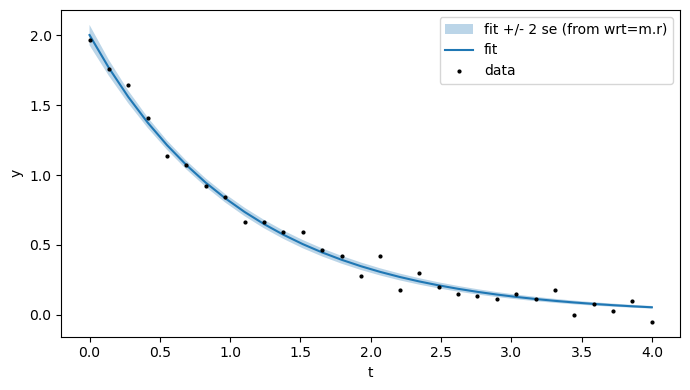

information(m, wrt=m.r) refuses:
  information: the wrt block is rank-deficient (more coordinates than the fit has degrees of freedom), so it carries no in ...


In [3]:
band = covariance(m, wrt=m.r)
se = np.sqrt(np.diag(band.matrix))
fit = np.array([pyo.value(m.A) * np.exp(-pyo.value(m.k) * ti)
                for ti in t_data])

plt.figure(figsize=(7, 4))
plt.fill_between(t_data, fit - 2 * se, fit + 2 * se,
                 alpha=0.3, label="fit +/- 2 se (from wrt=m.r)")
plt.plot(t_data, fit, label="fit")
plt.plot(t_data, y_data, "k.", ms=4, label="data")
plt.xlabel("t"); plt.ylabel("y"); plt.legend(); plt.tight_layout()
plt.show()

try:
    information(m, wrt=m.r)
except RuntimeError as e:
    print("information(m, wrt=m.r) refuses:\n ", str(e)[:120], "...")

## 3. `conditioned_on`: the answer's conditioning, returned

Pin `A` at a bound and ask about `k` alone. The block's number is the
value conditional on that bound, not the marginal over it, and the
result SAYS so: the strongly active variables outside the block come
back on `conditioned_on`.

In [4]:
m2 = build(t_data, y_data)
m2.A.setlb(pyo.value(m.A) + 0.2)
with warnings.catch_warnings(record=True):
    warnings.simplefilter("always")
    pyo.SolverFactory("pounce").solve(m2)
cov_k = covariance(m2, wrt=[m2.k])
print(f"var(k) conditional on the bound: {cov_k[m2.k]:.6g}")
print("conditioned on:", [v.name for v in cov_k.conditioned_on])

var(k) conditional on the bound: 0.000821036
conditioned on: ['A']


Conditioning is visible in the band. Recompute the prediction band on
the pinned solve: with `A` held by its bound, the remaining
uncertainty is `k` alone, and the band tightens most where `A`
dominated the curve, near `t = 0`.

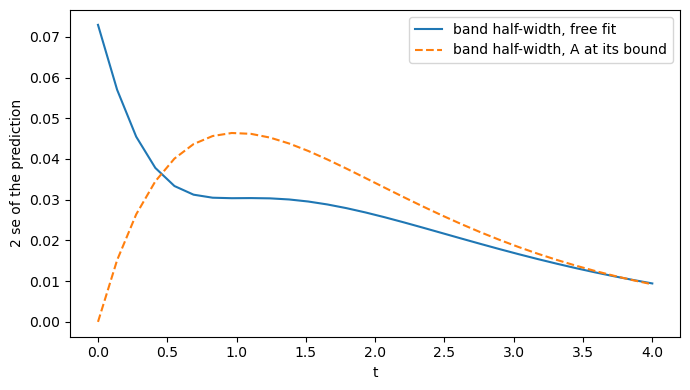

conditioned on: ['A']


In [5]:
band_pin = covariance(m2, wrt=m2.r)
se_pin = np.sqrt(np.diag(band_pin.matrix))

plt.figure(figsize=(7, 4))
plt.plot(t_data, 2 * se, label="band half-width, free fit")
plt.plot(t_data, 2 * se_pin, "--",
         label="band half-width, A at its bound")
plt.xlabel("t"); plt.ylabel("2 se of the prediction")
plt.legend(); plt.tight_layout()
plt.show()
print("conditioned on:", [v.name for v in band_pin.conditioned_on])

## 4. `retain_kkt()`: the declaration-free flow

The MHE pattern: nothing is THE fitted set, but the arrival state and
the parameters are each queried by `wrt=`. `retain_kkt(model)` keeps
the factor with no declaration; `covariance(model)` without a block
stays an error (there is no default to reduce onto), and a solve
without the call and without declarations pays nothing, exactly as
before.

In [6]:
m3 = build(t_data, y_data, declare=False)
retain_kkt(m3)
pyo.SolverFactory("pounce").solve(m3)

s2 = float(cov.sigma_sq)          # noise from the declared fit above
info_params = information(m3, wrt=[m3.A, m3.k])
print("parameter information via retain_kkt only:")
print(np.array2string(info_params.matrix, precision=3))

band3 = covariance(m3, sigma_sq=s2, wrt=m3.r)
print(f"\nband from the undeclared solve matches: "
      f"{np.max(np.abs(band3.matrix - band.matrix)):.2e}")

try:
    covariance(m3, sigma_sq=s2)
except RuntimeError as e:
    print("\ncovariance(m3) without wrt refuses:\n ", str(e)[:100], "...")

parameter information via retain_kkt only:
[[ 9.024 -8.718]
 [-8.718 19.169]]

band from the undeclared solve matches: 0.00e+00

covariance(m3) without wrt refuses:
  covariance: no fitted parameters were declared; flag the fitted variables with declare_fitted() befo ...


The retention policy in one place: the factor is kept if anything is
declared or `retain_kkt()` was called; a result object's unread lazy
`conditioned_on` keeps the session alive until first access; and an
undeclared solve without the call pays nothing.